# Quick Multi-Model Per-Dataset Single-Image Depth Check

Minimal notebook for running **one selected image per enabled dataset** through **all enabled depth models**, saving each prediction separately.

- No training
- No merged comparison grids
- One selected image per dataset, one output file per model

You can manually download and concatenate outputs later.


In [1]:
!git clone https://github.com/alooboii/EagleVision.git
%cd /kaggle/working/EagleVision

Cloning into 'EagleVision'...
remote: Enumerating objects: 289, done.
remote: Counting objects: 100% (289/289), done.
remote: Compressing objects: 100% (200/200), done.
remote: Total 289 (delta 109), reused 240 (delta 73), pack-reused 0 (from 0)
Receiving objects: 100% (289/289), 8.97 MiB | 11.88 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/kaggle/working/EagleVision


In [2]:
# Optional if needed in Kaggle runtime:
# !pip -q install -U datasets transformers matplotlib pillow tqdm

import os
import sys
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import pipeline

# EagleVision imports (repo must be available)

In [3]:
CONFIG = {
    # Kaggle paths
    "adapted_checkpoint_path": "/kaggle/input/models/rooonfr/best-adpated-100ep-scannet/pytorch/default/1/best_100ep.pt",
    "dav2_checkpoint_path": "baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth",

    # model settings (for EagleVision wrappers)
    "depth_mode": "metric",
    "encoder": "vits",
    "profile": "hypersim",
    "adapter_hidden_channels": 32,
    "normalize_backbone_input": False,

    # per-dataset single-image settings
    "random_sample_per_dataset": True,
    "random_seed": 7,
    "single_sample_index_per_dataset": 0,  # used only when random_sample_per_dataset=False
    "save_outputs": True,
    "save_raw_npy": True,
    "output_dir": "outputs/quick_depth_single_image_all_models",

    # datasets to source one sample each from
    "datasets": [
        {"name": "nyu_depth_v2_hf", "type": "hf_nyu", "split": "validation", "enabled": True},
        {"name": "cifar100_val", "type": "hf_rgb", "hf_dataset": "cifar100", "split": "test", "image_key": "img", "enabled": True},
        {"name": "beans_val", "type": "hf_rgb", "hf_dataset": "beans", "split": "train", "image_key": "image", "enabled": True},
        {"name": "food101_val", "type": "hf_rgb", "hf_dataset": "food101", "split": "validation", "image_key": "image", "enabled": True},
        # optional local scannet-style samples
        {"name": "kaggle_scannet_2d", "type": "local_scannet_style", "root": "/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d", "enabled": False},
    ],

    # model registry (enable/disable as needed)
    "models": [
        {"id": "ours_adapted", "kind": "eaglevision_adapted", "enabled": True},
        {"id": "ours_dav2_base", "kind": "eaglevision_base", "enabled": True},

        {"id": "depth_anything_v2_small", "kind": "hf_pipeline", "hf_model": "depth-anything/Depth-Anything-V2-Small-hf", "enabled": True},
        {"id": "depth_anything_v2_base", "kind": "hf_pipeline", "hf_model": "depth-anything/Depth-Anything-V2-Base-hf", "enabled": True},
        {"id": "depth_anything_v2_large", "kind": "hf_pipeline", "hf_model": "depth-anything/Depth-Anything-V2-Large-hf", "enabled": True},
        {"id": "depth_anything_v1_small", "kind": "hf_pipeline", "hf_model": "LiheYoung/depth-anything-small-hf", "enabled": True},
        {"id": "dpt_large", "kind": "hf_pipeline", "hf_model": "Intel/dpt-large", "enabled": True},
        {"id": "zoedepth_nyu_kitti", "kind": "hf_pipeline", "hf_model": "Intel/zoedepth-nyu-kitti", "enabled": True},

        # optional heavy model
        {"id": "midas_dpt_large", "kind": "torchhub_midas", "model_type": "DPT_Large", "enabled": False},
    ],
}

assert CONFIG["adapted_checkpoint_path"]
assert CONFIG["dav2_checkpoint_path"]

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

KAGGLE_WORKING = Path("/kaggle/working")
RUNNING_ON_KAGGLE = KAGGLE_WORKING.exists()
REPO_DIR = (KAGGLE_WORKING / "EagleVision") if (RUNNING_ON_KAGGLE and (KAGGLE_WORKING / "EagleVision").exists()) else Path.cwd().resolve()

SRC_DIR = REPO_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from eaglevision.models.depth.depth_anything_wrapper import DepthAnythingWithAdapter
from eaglevision.models.rt_depthnvs import RoundTripDepthNVS
from eaglevision.engine.checkpointing import load_checkpoint

OUT_DIR = REPO_DIR / CONFIG["output_dir"]
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo:", REPO_DIR)
print("output:", OUT_DIR)

device: cuda
repo: /kaggle/working/EagleVision
output: /kaggle/working/EagleVision/outputs/quick_depth_preview


In [6]:
import subprocess, sys
from pathlib import Path

ckpt = REPO_DIR / "baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth"
ckpt.parent.mkdir(parents=True, exist_ok=True)

if not ckpt.exists():
    print("DAV2 checkpoint missing, downloading...")
    cmd = [
        sys.executable, "-m", "baseline.depth_anything_v2", "download",
        "--mode", "all",
        "--profile", CONFIG["profile"],
        "--encoder", CONFIG["encoder"],
    ]
    res = subprocess.run(cmd, cwd=REPO_DIR, text=True, capture_output=True)
    print(res.stdout[-1200:])
    if res.returncode != 0:
        print(res.stderr[-1200:])
        raise RuntimeError("DAV2 download failed. Enable internet or attach checkpoint as Kaggle input.")
else:
    print("DAV2 checkpoint already exists:", ckpt)

print("Exists now:", ckpt.exists(), ckpt)


DAV2 checkpoint missing, downloading...
relative:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_vits.pth (downloaded)
metric:hypersim:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth (downloaded)

Exists now: True /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth


In [7]:
def resolve_ckpt(path_str: str, default_name: str | None = None) -> Path:
    p = Path(path_str)
    if not p.is_absolute():
        p = (REPO_DIR / p).resolve()
    if p.is_file():
        return p
    if p.is_dir():
        if default_name:
            c = p / default_name
            if c.is_file():
                return c
        cands = sorted(list(p.rglob("*.pth")) + list(p.rglob("*.pt")))
        if cands:
            return cands[0]
    raise FileNotFoundError(f"Checkpoint not found: {p}")


dav2_ckpt = resolve_ckpt(
    CONFIG["dav2_checkpoint_path"],
    default_name=f"depth_anything_v2_metric_{CONFIG['profile']}_{CONFIG['encoder']}.pth",
)
adapted_ckpt = resolve_ckpt(CONFIG["adapted_checkpoint_path"], default_name="best_100ep.pt")

print("dav2:", dav2_ckpt)
print("adapted:", adapted_ckpt)

dav2: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
adapted: /kaggle/input/models/rooonfr/best-adpated-100ep-scannet/pytorch/default/1/best_100ep.pt


In [8]:
def _to_tensor_rgb(image: Image.Image) -> torch.Tensor:
    arr = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)


class BaseEstimator:
    def predict(self, image: Image.Image):
        raise NotImplementedError


class EagleVisionAdaptedEstimator(BaseEstimator):
    def __init__(self):
        depth_model = DepthAnythingWithAdapter(
            mode=CONFIG["depth_mode"],
            encoder=CONFIG["encoder"],
            profile=CONFIG["profile"],
            checkpoint_path=dav2_ckpt,
            freeze_backbone=True,
            adapter_hidden_channels=CONFIG["adapter_hidden_channels"],
            normalize_backbone_input=CONFIG["normalize_backbone_input"],
        ).to(DEVICE).eval()
        self.model = RoundTripDepthNVS(depth_model).to(DEVICE).eval()
        load_checkpoint(adapted_ckpt, self.model)

    @torch.no_grad()
    def predict(self, image: Image.Image):
        x = _to_tensor_rgb(image).unsqueeze(0).to(DEVICE)
        out = self.model.depth_model(x)["adapted_depth"]
        return out


class EagleVisionBaseEstimator(BaseEstimator):
    def __init__(self):
        self.model = DepthAnythingWithAdapter(
            mode=CONFIG["depth_mode"],
            encoder=CONFIG["encoder"],
            profile=CONFIG["profile"],
            checkpoint_path=dav2_ckpt,
            freeze_backbone=True,
            adapter_hidden_channels=CONFIG["adapter_hidden_channels"],
            normalize_backbone_input=CONFIG["normalize_backbone_input"],
        ).to(DEVICE).eval()

    @torch.no_grad()
    def predict(self, image: Image.Image):
        x = _to_tensor_rgb(image).unsqueeze(0).to(DEVICE)
        out = self.model(x)["base_depth"]
        return out


class HFPipelineEstimator(BaseEstimator):
    def __init__(self, model_id: str):
        self.pipe = pipeline("depth-estimation", model=model_id, device=0 if DEVICE.type == "cuda" else -1)

    def predict(self, image: Image.Image):
        out = self.pipe(image)
        if "predicted_depth" in out:
            return out["predicted_depth"]
        return out["depth"]


class MiDaSEstimator(BaseEstimator):
    def __init__(self, model_type: str = "DPT_Large"):
        self.model = torch.hub.load("intel-isl/MiDaS", model_type).to(DEVICE).eval()
        transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        self.transform = transforms.dpt_transform if "DPT" in model_type else transforms.small_transform

    @torch.no_grad()
    def predict(self, image: Image.Image):
        arr = np.asarray(image.convert("RGB"))
        inp = self.transform(arr).to(DEVICE)
        pred = self.model(inp)
        pred = F.interpolate(pred.unsqueeze(1), size=arr.shape[:2], mode="bicubic", align_corners=False).squeeze()
        return pred


def try_build_estimator(spec: dict[str, Any]):
    try:
        kind = spec["kind"]
        if kind == "eaglevision_adapted":
            return EagleVisionAdaptedEstimator(), None
        if kind == "eaglevision_base":
            return EagleVisionBaseEstimator(), None
        if kind == "hf_pipeline":
            return HFPipelineEstimator(spec["hf_model"]), None
        if kind == "torchhub_midas":
            return MiDaSEstimator(spec.get("model_type", "DPT_Large")), None
        return None, f"Unknown model kind: {kind}"
    except Exception as e:
        return None, repr(e)

Loaded adapted model checkpoint.


In [9]:
def to_depth_2d(pred, target_hw=None) -> np.ndarray:
    if torch.is_tensor(pred):
        pred = pred.detach().cpu().numpy()
    if isinstance(pred, Image.Image):
        pred = np.asarray(pred)

    pred = np.asarray(pred)

    while pred.ndim > 2 and pred.shape[0] == 1:
        pred = pred[0]

    if pred.ndim == 3:
        if pred.shape[-1] in (1, 3, 4):
            pred = pred[..., 0]
        else:
            pred = pred[0]

    if pred.ndim == 1:
        if target_hw is None:
            raise ValueError(f"1D depth output {pred.shape} without target_hw")
        h, w = target_hw
        n = pred.shape[0]
        if n == w:
            pred = np.tile(pred[None, :], (h, 1))
        elif n == h:
            pred = np.tile(pred[:, None], (1, w))
        elif n == h * w:
            pred = pred.reshape(h, w)
        else:
            raise ValueError(f"Cannot reshape 1D depth of length {n} to {(h, w)}")

    if pred.ndim != 2:
        raise ValueError(f"Expected 2D depth map, got shape {pred.shape}")

    return pred.astype(np.float32)


def resize_depth_like_np(pred_2d: np.ndarray, h: int, w: int) -> np.ndarray:
    t = torch.from_numpy(pred_2d).unsqueeze(0).unsqueeze(0).float()
    out = F.interpolate(t, size=(h, w), mode="bilinear", align_corners=False)
    return out[0, 0].cpu().numpy().astype(np.float32)


def robust_range(depth: np.ndarray):
    m = np.isfinite(depth)
    if m.sum() == 0:
        return 0.0, 1.0
    lo, hi = np.percentile(depth[m], [2, 98])
    if hi <= lo:
        hi = lo + 1e-6
    return float(lo), float(hi)

In [10]:
def load_hf_nyu_images(split: str, n: int):
    ds = None
    errors = []
    for cand in [
        {"path": "sayakpaul/nyu_depth_v2", "kwargs": {"revision": "refs/convert/parquet"}},
        {"path": "sayakpaul/nyu_depth_v2", "kwargs": {}},
    ]:
        try:
            ds = load_dataset(cand["path"], split=split, **cand["kwargs"])
            break
        except Exception as e:
            errors.append(str(e))
    if ds is None:
        raise RuntimeError("NYU load failed: " + " | ".join(errors))

    out = []
    for i in range(min(n, len(ds))):
        ex = ds[i]
        out.append({"dataset": "nyu_depth_v2_hf", "sample_id": f"nyu_{i:06d}", "image": ex["image"].convert("RGB")})
    return out


def load_hf_rgb_images(dataset_name: str, split: str, image_key: str, n: int, label: str):
    ds = load_dataset(dataset_name, split=split)
    out = []
    for i in range(min(n, len(ds))):
        im = ds[i][image_key]
        if not isinstance(im, Image.Image):
            im = Image.fromarray(np.asarray(im))
        out.append({"dataset": label, "sample_id": f"{label}_{i:06d}", "image": im.convert("RGB")})
    return out


def load_local_scannet_images(root: str, n: int):
    rootp = Path(root)
    rows = []
    if not rootp.exists():
        return rows
    scenes = sorted([p for p in rootp.glob("*") if p.is_dir()])
    for scene in scenes:
        cdir = next((d for d in [scene / "color", scene / "rgb", scene / "images"] if d.exists()), None)
        if cdir is None:
            continue
        for cp in sorted(cdir.glob("*.jpg")) + sorted(cdir.glob("*.png")):
            rows.append({"dataset": "kaggle_scannet_2d", "sample_id": f"{scene.name}_{cp.stem}", "image": Image.open(cp).convert("RGB")})
            if len(rows) >= n:
                return rows
    return rows

In [11]:
# Select one sample from each enabled dataset
use_random = bool(CONFIG.get("random_sample_per_dataset", True))
fixed_idx = int(CONFIG.get("single_sample_index_per_dataset", 0))
seed = CONFIG.get("random_seed", None)
rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

# Load a reasonable pool per dataset; random pick is drawn from this pool
min_pool = max(8, fixed_idx + 1)

selected_samples = []

for d in CONFIG["datasets"]:
    if not d.get("enabled", False):
        continue

    try:
        if d["type"] == "hf_nyu":
            samples = load_hf_nyu_images(d.get("split", "validation"), min_pool)
        elif d["type"] == "hf_rgb":
            samples = load_hf_rgb_images(
                d["hf_dataset"],
                d.get("split", "train"),
                d.get("image_key", "image"),
                min_pool,
                d["name"],
            )
        elif d["type"] == "local_scannet_style":
            samples = load_local_scannet_images(d["root"], min_pool)
        else:
            samples = []

        print(f"{d['name']}: loaded {len(samples)} samples")
        if len(samples) == 0:
            print("  [skip] no samples available")
            continue

        if use_random:
            idx = int(rng.integers(0, len(samples)))
        else:
            if fixed_idx < 0 or fixed_idx >= len(samples):
                print(f"  [skip] index {fixed_idx} out of range (have {len(samples)})")
                continue
            idx = fixed_idx

        chosen = samples[idx]
        selected_samples.append(chosen)
        print(f"  selected idx={idx} -> {chosen['dataset']} | {chosen['sample_id']}")

        if CONFIG["save_outputs"]:
            rgb_path = OUT_DIR / f"{chosen['dataset']}__{chosen['sample_id']}__rgb.png"
            chosen["image"].save(rgb_path)
            print("  saved RGB:", rgb_path)

    except Exception as e:
        print(f"[skip dataset] {d['name']}: {e}")

if len(selected_samples) == 0:
    raise RuntimeError("No per-dataset samples selected. Check dataset settings and index.")

print("\nTotal selected samples:", len(selected_samples))

default/partial-train/0000.parquet:   0%|          | 0.00/217M [00:00<?, ?B/s]

default/partial-train/0001.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

default/partial-train/0002.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

default/partial-train/0003.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/partial-train/0004.parquet:   0%|          | 0.00/234M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

food101_val: 3 samples
Total preview samples: 12


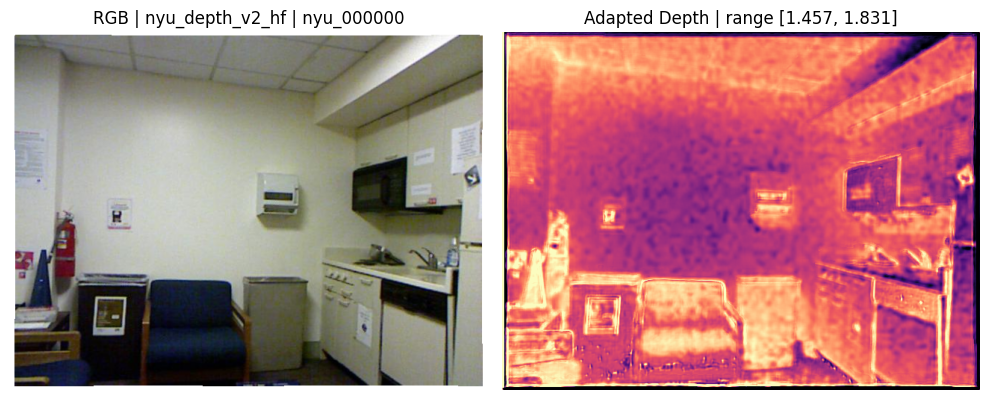

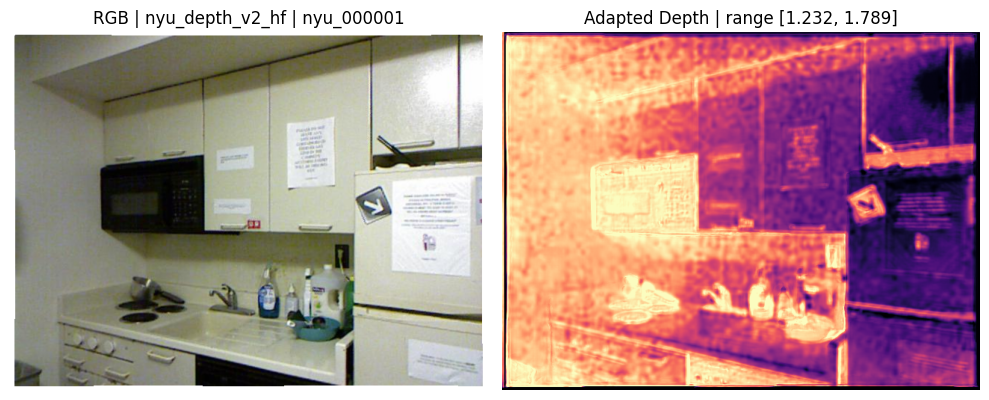

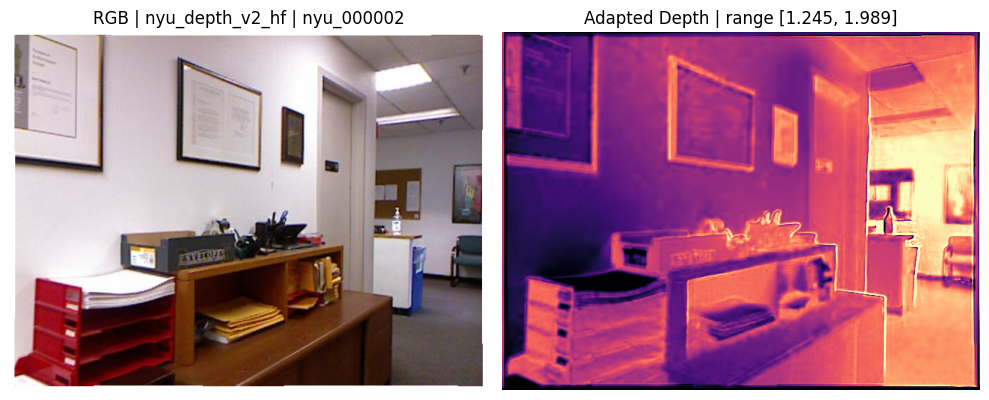

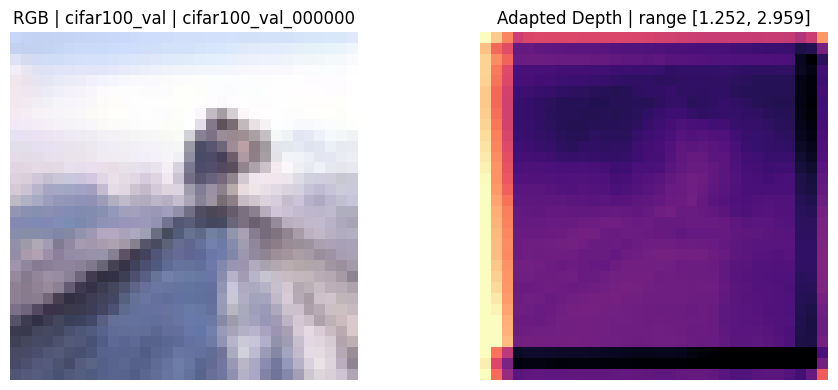

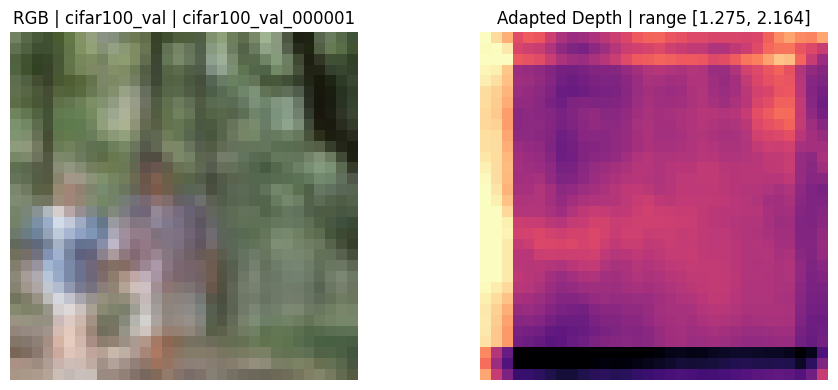

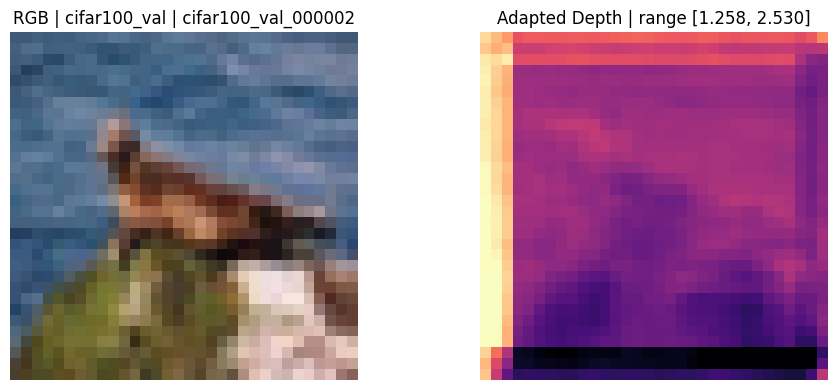

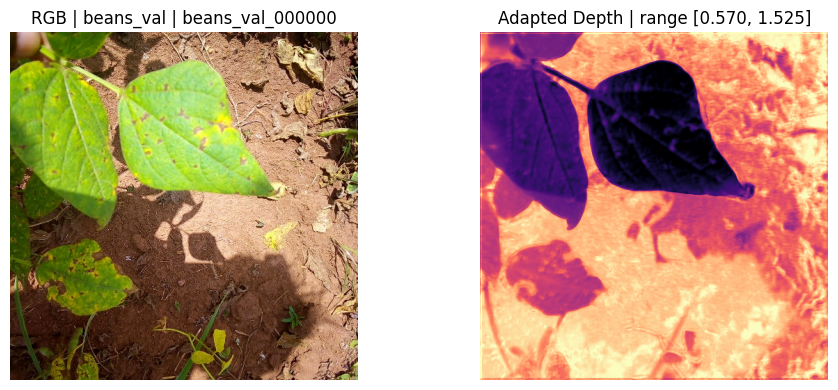

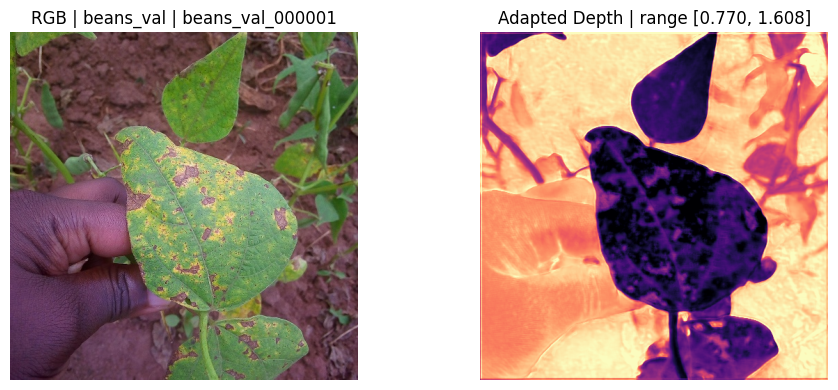

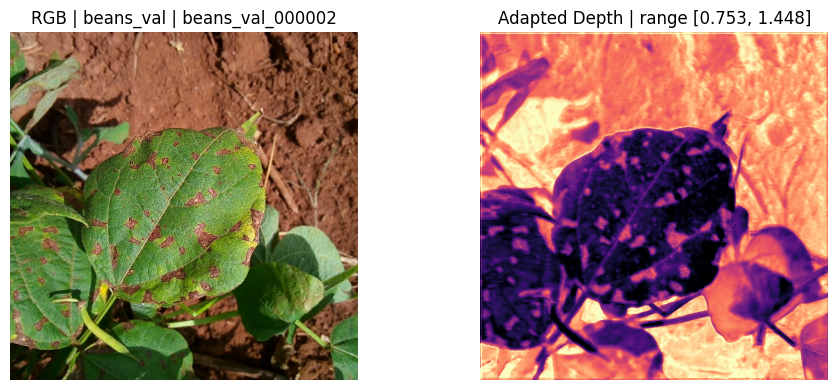

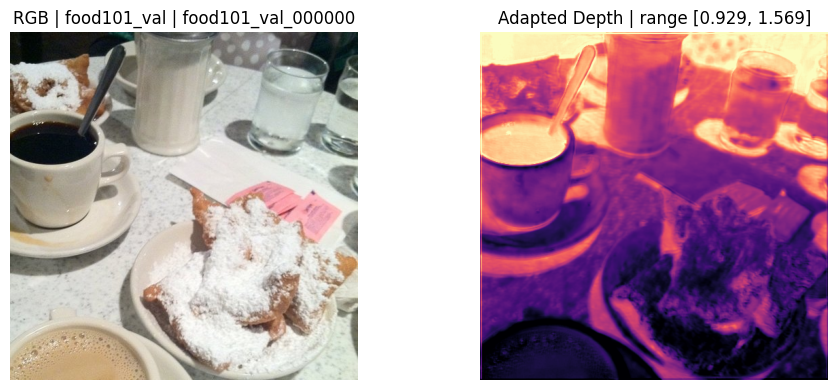

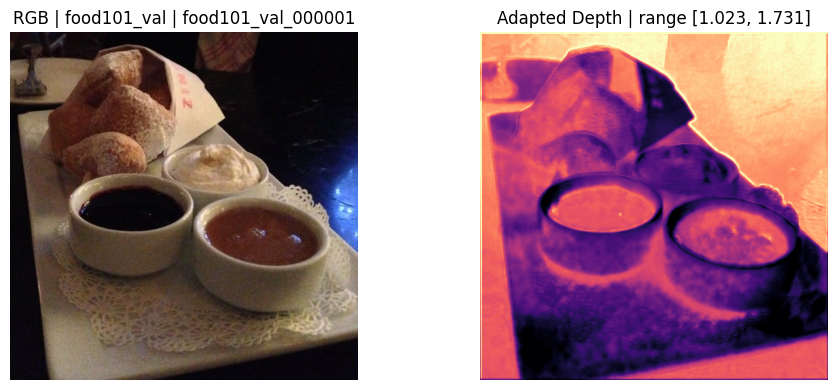

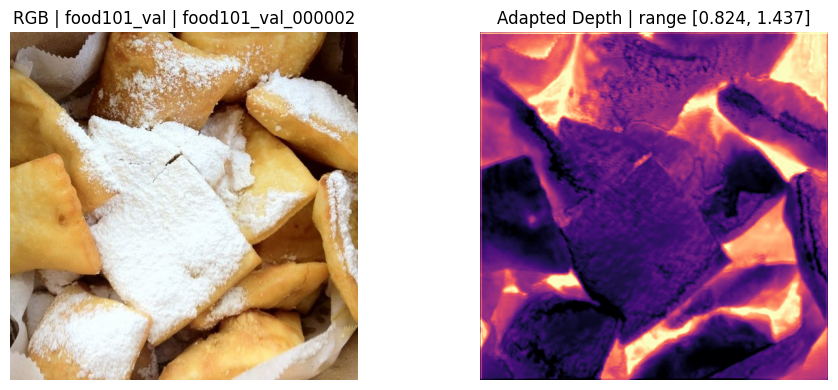

Done. Saved outputs to: /kaggle/working/EagleVision/outputs/quick_depth_preview


In [12]:
# Build enabled models
enabled_models = [m for m in CONFIG["models"] if m.get("enabled", False)]
print("Enabled models:")
for m in enabled_models:
    print(" -", m["id"])

estimators = {}
failed = {}

for spec in enabled_models:
    print("Loading model:", spec["id"])
    est, err = try_build_estimator(spec)
    if est is None:
        failed[spec["id"]] = err
        print("  [failed]", err)
    else:
        estimators[spec["id"]] = est
        print("  [ok]")

if len(estimators) == 0:
    raise RuntimeError(f"No model loaded successfully. Failed: {failed}")

for sample in selected_samples:
    img = sample["image"].convert("RGB")
    dname = sample["dataset"]
    sid = sample["sample_id"]
    h, w = img.height, img.width

    print(f"\n=== Sample: {dname} | {sid} ===")

    for mid, est in estimators.items():
        try:
            raw_pred = est.predict(img)
            pred_2d = to_depth_2d(raw_pred, target_hw=(h, w))
            if pred_2d.shape != (h, w):
                pred_2d = resize_depth_like_np(pred_2d, h, w)

            vmin, vmax = robust_range(pred_2d)

            # Show singular output for this model (not a comparison grid)
            fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            ax[0].imshow(np.asarray(img))
            ax[0].set_title(f"RGB | {dname} | {sid}")
            ax[0].axis("off")

            ax[1].imshow(pred_2d, cmap="magma", vmin=vmin, vmax=vmax)
            ax[1].set_title(f"{mid} | depth [{vmin:.3f}, {vmax:.3f}]")
            ax[1].axis("off")
            plt.tight_layout()
            plt.show()

            if CONFIG["save_outputs"]:
                out_png = OUT_DIR / f"{dname}__{sid}__{mid}__depth.png"
                norm = np.clip((pred_2d - vmin) / max(vmax - vmin, 1e-6), 0, 1)
                color = (plt.get_cmap("magma")(norm)[..., :3] * 255).astype(np.uint8)
                Image.fromarray(color).save(out_png)
                print("saved:", out_png)

                if CONFIG.get("save_raw_npy", True):
                    out_npy = OUT_DIR / f"{dname}__{sid}__{mid}__depth.npy"
                    np.save(out_npy, pred_2d.astype(np.float32))
                    print("saved:", out_npy)

        except Exception as e:
            print(f"[predict failed] {mid}: {e}")

if failed:
    print("\nModels that failed to load:")
    for k, v in failed.items():
        print(" -", k, "=>", v)

print("\nDone. Outputs in:", OUT_DIR)